# Assignment 2
by Dev Srivastava

In [1]:
!wget https://warwick.ac.uk/fac/sci/dcs/teaching/material/cs909/patches_256.zip

--2026-03-23 10:08:31--  https://warwick.ac.uk/fac/sci/dcs/teaching/material/cs909/patches_256.zip
Resolving warwick.ac.uk (warwick.ac.uk)... 137.205.28.41
Connecting to warwick.ac.uk (warwick.ac.uk)|137.205.28.41|:443... connected.
HTTP request sent, awaiting response... 200 
Length: 1729436294 (1.6G) [application/zip]
Saving to: ‘patches_256.zip’

patches_256.zip     100%[===================>]   1.61G  7.56MB/s    in 8m 18s  

2026-03-23 10:16:49 (3.31 MB/s) - ‘patches_256.zip’ saved [1729436294/1729436294]



In [2]:
!unzip /content/patches_256.zip -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/patches_256/C1_36x70.png  
  inflating: /content/patches_256/C1_36x72.png  
  inflating: /content/patches_256/C1_36x74.png  
  inflating: /content/patches_256/C1_36x76.png  
  inflating: /content/patches_256/C1_36x78.png  
  inflating: /content/patches_256/C1_36x80.png  
  inflating: /content/patches_256/C1_36x82.png  
  inflating: /content/patches_256/C1_36x84.png  
  inflating: /content/patches_256/C1_36x86.png  
  inflating: /content/patches_256/C1_36x88.png  
  inflating: /content/patches_256/C1_36x90.png  
  inflating: /content/patches_256/C1_36x92.png  
  inflating: /content/patches_256/C1_36x94.png  
  inflating: /content/patches_256/C1_36x96.png  
  inflating: /content/patches_256/C1_36x98.png  
  inflating: /content/patches_256/C1_37x101.png  
  inflating: /content/patches_256/C1_37x103.png  
  inflating: /content/patches_256/C1_37x105.png  
  inflating: /content/patches_256/C1_37x107.png  
  inflating: /

## Download and load expression data into a dataframe

This data can be read using this code (not to be changed). Each row in the resulting data frame contains information about a single spot such as its spatial location coordinates (Location_Center_Y, Location_Center_X) and the expression values of 38 different proteins. The names of the proteins are given in the list “proteins_names”.  The code  also creates two additional columns 'specimen_id' and 'image_id' which will be needed for this assignment. df.specimen_id contains the identifier or name of the specimen (A1, B1, C1 or D1) from which the spot originates.  df.image_id contains the file name of the image file corresponding to each spot (without the png extension).

Note there may be some images for which no expression is available. You can drop those images.


In [3]:
import pandas as pd
df = pd.read_csv('https://warwick.ac.uk/fac/sci/dcs/teaching/material/cs909/protein_expression_data.csv')


df['specimen_id']=df.VisSpot.apply(lambda x: x.split('-')[2]) #create specimen id field
df['image_id']=df.VisSpot.apply(lambda x: x.split('-')[2])+'_'+df.id #create image id field
df = df.set_index('image_id').sort_index()
protein_names = ['SMAa', 'CD11b',
       'CD44', 'CD31', 'CDK4', 'YKL40', 'CD11c', 'HIF1a', 'CD24', 'TMEM119',
       'OLIG2', 'GFAP', 'VISTA', 'IBA1', 'CD206', 'PTEN', 'NESTIN', 'TCIRG1',
       'CD74', 'MET', 'P2RY12', 'CD163', 'S100B', 'cMYC', 'pERK', 'EGFR',
       'SOX2', 'HLADR', 'PDGFRa', 'MCT4', 'DNA1', 'DNA3', 'MHCI', 'CD68',
       'CD14', 'KI67', 'CD16', 'SOX10']
print(df)


          Unnamed: 0                VisSpot  Location_Center_Y  \
image_id                                                         
A1_0x40          412  AAGTAAGCTTCCAAAC-1-A1         764.003658   
A1_0x42         7325  GTTTGAGCGGTTATGT-1-A1         799.511111   
A1_0x44         8102  TCACTCAGCGCATTAG-1-A1         832.902467   
A1_0x46         7085  GTGCGCTTACAAATGA-1-A1         858.343544   
A1_0x48         3748  CGAAGACTGCCCGGGA-1-A1         892.179831   
...              ...                    ...                ...   
D1_9x63         3609  CCTCCCGACAATCCCT-1-D1         123.760525   
D1_9x65          172  AACACGACTGTACTGA-1-D1          29.281573   
D1_9x67         2686  CACCGCCGACCAGCGA-1-D1         938.403662   
D1_9x69         2813  CAGAGTGATTTAACGT-1-D1         844.093656   
D1_9x71         6877  GTCAGTTGTGCTCGTT-1-D1         740.107483   

          Location_Center_X      SMAa     CD11b      CD44      CD31      CDK4  \
image_id                                                    

## Showing an example image

The code below will load an example image. It also shows how you can get the HED channels.

skimage version 0.25.2


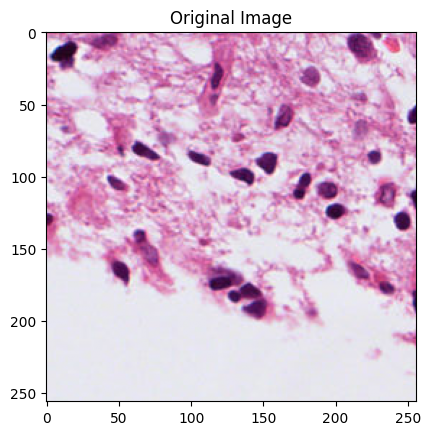

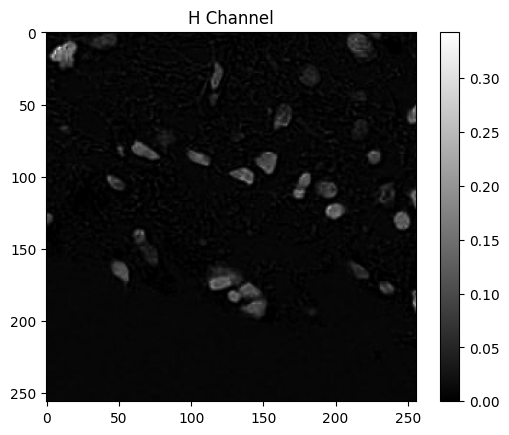

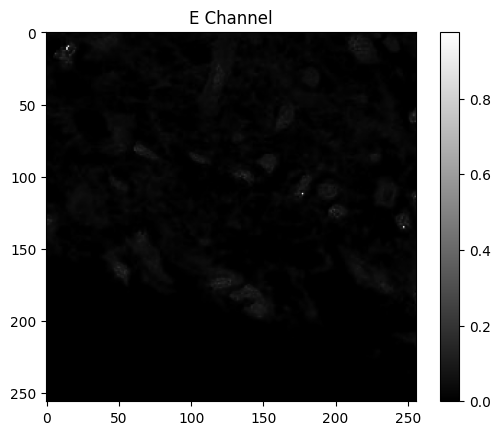

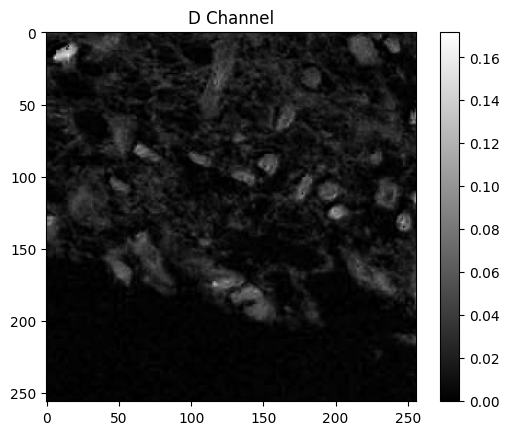

In [4]:
image_folder = '/content/patches_256/'
from skimage.color import rgb2hed
import skimage
from skimage.io import imread
from skimage.color import rgba2rgb
import matplotlib.pyplot as plt

# Replace 'path_to_image' with the path to the image you want to display
image_path = image_folder+'A1_0x40.png'
print('skimage version',skimage.__version__)
import matplotlib.pyplot as plt
I = rgba2rgb(imread(image_path)) #read sample RGB image
I_hed =  rgb2hed(I) #convert to HED
plt.imshow(I);plt.title('Original Image');plt.show()
I_h = I_hed[:,:,0]; plt.figure(); plt.imshow(I_h,cmap='gray');plt.colorbar();plt.title('H Channel');plt.show()
I_e = I_hed[:,:,1]; plt.figure();  plt.imshow(I_e,cmap='gray');plt.colorbar();plt.title('E Channel');plt.show()
I_d = I_hed[:,:,2]; plt.figure();  plt.imshow(I_d,cmap='gray');plt.colorbar();plt.title('D Channel');plt.show()


## QUESTION 1 – Shared Structure Between Image and Protein Spaces


### 1. Construct Protein Feature Space

In [5]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Separate data into training (A1, B1, C1) and testing (D1)
train_specimens = ['A1', 'B1', 'C1']
df_train = df[df['specimen_id'].isin(train_specimens)]
df_test = df[df['specimen_id'] == 'D1']

# Extract protein expression data
X_protein_train = df_train[protein_names].values
X_protein_test = df_test[protein_names].values

# Standardise using StandardScaler (fit only on training data)
scaler_protein = StandardScaler()
X_protein_train_scaled = scaler_protein.fit_transform(X_protein_train)
X_protein_test_scaled = scaler_protein.transform(X_protein_test)

print(f"Shape of raw protein features (training): {X_protein_train.shape}")
print(f"Shape of scaled protein features (training): {X_protein_train_scaled.shape}")
print(f"Shape of raw protein features (testing): {X_protein_test.shape}")
print(f"Shape of scaled protein features (testing): {X_protein_test_scaled.shape}")

Shape of raw protein features (training): (8168, 38)
Shape of scaled protein features (training): (8168, 38)
Shape of raw protein features (testing): (1753, 38)
Shape of scaled protein features (testing): (1753, 38)


### 2. Construct Image Feature Space

In [6]:
from skimage.color import rgb2gray
from skimage.transform import resize
from skimage.io import imread
from skimage.color import rgba2rgb
import os

# Function to load, process, and flatten image
def process_image(image_id, folder_path):
    image_path = os.path.join(folder_path, f'{image_id}.png')
    try:
        img = imread(image_path)
        # Check if the image has an alpha channel (4 channels)
        if img.shape[-1] == 4:
            img_rgb = rgba2rgb(img)
        elif img.shape[-1] == 3:
            img_rgb = img
        else:
            # Handle other cases if necessary, or raise an error
            print(f"Warning: Image {image_id} has unexpected number of channels: {img.shape[-1]}. Skipping.")
            return None

        img_gray = rgb2gray(img_rgb)
        img_resized = resize(img_gray, (32, 32), anti_aliasing=True)
        return img_resized.flatten()
    except FileNotFoundError:
        print(f"Warning: Image file not found for {image_id}. Skipping.")
        return None

# Process images for training set
image_features_train = []
image_ids_train = []
for img_id in df_train.index.unique():
    processed_img = process_image(img_id, image_folder)
    if processed_img is not None:
        image_features_train.append(processed_img)
        image_ids_train.append(img_id)
X_image_train = np.array(image_features_train)

# Process images for testing set
image_features_test = []
image_ids_test = []
for img_id in df_test.index.unique():
    processed_img = process_image(img_id, image_folder)
    if processed_img is not None:
        image_features_test.append(processed_img)
        image_ids_test.append(img_id)
X_image_test = np.array(image_features_test)

# Ensure the protein data aligns with available image data after filtering
# Create a new df_train_filtered and df_test_filtered that only contain rows for which images were found
df_train_filtered = df_train.loc[image_ids_train]
df_test_filtered = df_test.loc[image_ids_test]
X_protein_train_scaled_filtered = df_train_filtered[protein_names].values
X_protein_test_scaled_filtered = df_test_filtered[protein_names].values

# Initialize with the full scaled data from the protein section
current_X_protein_train_scaled = X_protein_train_scaled
current_X_protein_test_scaled = X_protein_test_scaled

# Check if filtering reduced the number of samples for protein data
if X_protein_train_scaled_filtered.shape[0] != X_protein_train.shape[0]:
    print("Re-standardizing protein training data due to image availability mismatch.")
    # Create a new scaler for the filtered data
    scaler_protein_filtered = StandardScaler()
    current_X_protein_train_scaled = scaler_protein_filtered.fit_transform(X_protein_train_scaled_filtered)
    current_X_protein_test_scaled = scaler_protein_filtered.transform(X_protein_test_scaled_filtered)
else:
    # If no filtering occurred, use the pre-existing scaled data from the initial protein feature space step
    # This 'else' block ensures X_protein_train_scaled and X_protein_test_scaled refer to the correct arrays after this process.
    current_X_protein_train_scaled = df_train_filtered[protein_names].values
    current_X_protein_test_scaled = df_test_filtered[protein_names].values
    # For consistency, it's safer to re-initialize and fit the scaler if dealing with potentially new subsets.
    scaler_protein_recheck = StandardScaler()
    current_X_protein_train_scaled = scaler_protein_recheck.fit_transform(current_X_protein_train_scaled)
    current_X_protein_test_scaled = scaler_protein_recheck.transform(current_X_protein_test_scaled)

X_protein_train_scaled = current_X_protein_train_scaled
X_protein_test_scaled = current_X_protein_test_scaled


# Standardise image features (fit only on training data)
scaler_image = StandardScaler()
X_image_train_scaled = scaler_image.fit_transform(X_image_train)
X_image_test_scaled = scaler_image.transform(X_image_test)

print(f"Shape of raw image features (training): {X_image_train.shape}")
print(f"Shape of scaled image features (training): {X_image_train_scaled.shape}")
print(f"Shape of raw image features (testing): {X_image_test.shape}")
print(f"Shape of scaled image features (testing): {X_image_test_scaled.shape}")

print(f"Final Shape of scaled protein features (training) after image alignment: {X_protein_train_scaled.shape}")
print(f"Final Shape of scaled protein features (testing) after image alignment: {X_protein_test_scaled.shape}")

Shape of raw image features (training): (8168, 1024)
Shape of scaled image features (training): (8168, 1024)
Shape of raw image features (testing): (1753, 1024)
Shape of scaled image features (testing): (1753, 1024)
Final Shape of scaled protein features (training) after image alignment: (8168, 38)
Final Shape of scaled protein features (testing) after image alignment: (1753, 38)


### 3. PCA Analysis

-  To understand the structure of both the protein and image features, I applied Principal Component Analysis (PCA) to each dataset separately. PCA helps reduce dimensionality while keeping most of the important information.

- I then plotted the variance explained by each principal component (scree plot) and also looked at the cumulative explained variance. This allowed me to estimate how many components are needed to capture around 90% of the total variance in each case.

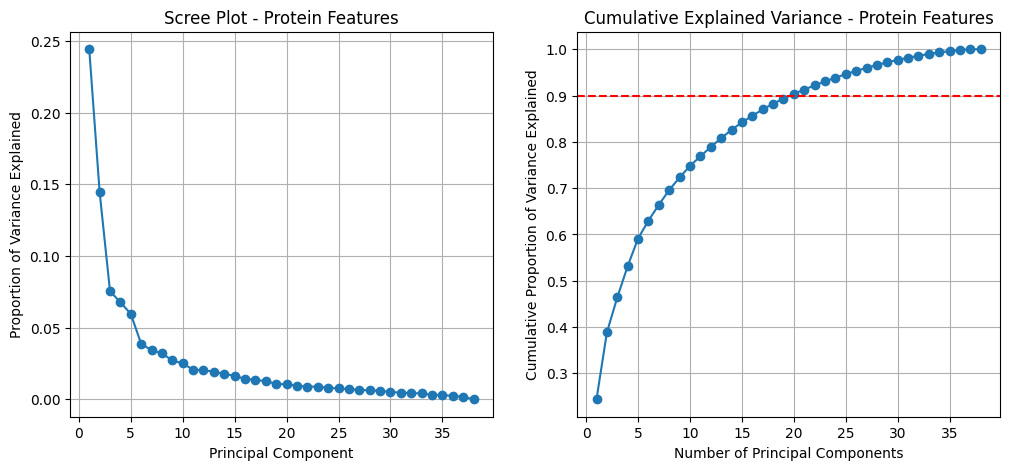

Number of components explaining 90% variance for Protein Features: 20


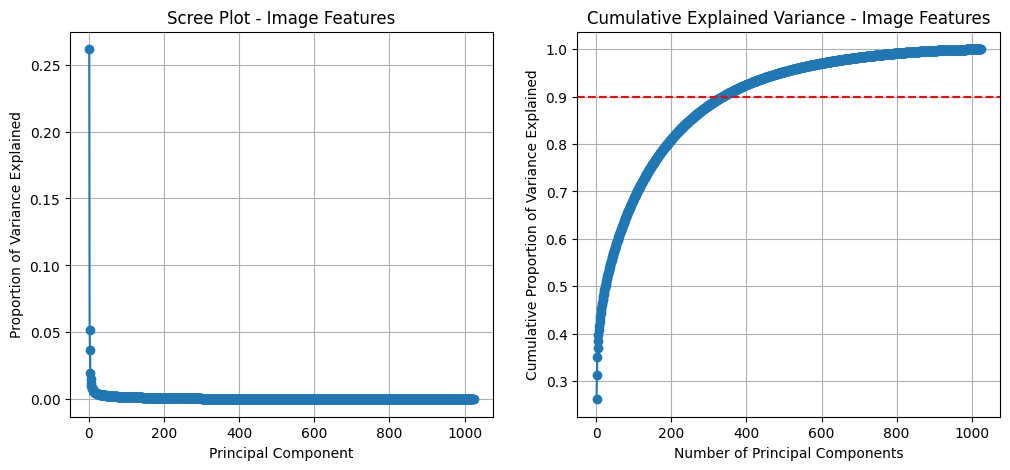

Number of components explaining 90% variance for Image Features: 336
Shape of PCA-transformed protein features (training): (8168, 20)
Shape of PCA-transformed protein features (testing): (1753, 20)
Shape of PCA-transformed image features (training): (8168, 336)
Shape of PCA-transformed image features (testing): (1753, 336)


In [7]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def plot_pca_results(pca_model, title):
    plt.figure(figsize=(12, 5))

    # Scree Plot
    plt.subplot(1, 2, 1)
    plt.plot(range(1, len(pca_model.explained_variance_ratio_) + 1), pca_model.explained_variance_ratio_, marker='o')
    plt.title(f'Scree Plot - {title}')
    plt.xlabel('Principal Component')
    plt.ylabel('Proportion of Variance Explained')
    plt.grid(True)

    # Cumulative Explained Variance Plot
    plt.subplot(1, 2, 2)
    plt.plot(range(1, len(pca_model.explained_variance_ratio_) + 1), np.cumsum(pca_model.explained_variance_ratio_), marker='o')
    plt.title(f'Cumulative Explained Variance - {title}')
    plt.xlabel('Number of Principal Components')
    plt.ylabel('Cumulative Proportion of Variance Explained')
    plt.axhline(y=0.9, color='r', linestyle='--')
    plt.grid(True)
    plt.show()

    # Determine number of components for 90% variance
    cumulative_variance = np.cumsum(pca_model.explained_variance_ratio_)
    n_components_90 = np.where(cumulative_variance >= 0.9)[0][0] + 1
    print(f"Number of components explaining 90% variance for {title}: {n_components_90}")
    return n_components_90

# PCA for Protein Features
pca_protein = PCA()
pca_protein.fit(X_protein_train_scaled)
n_components_protein = plot_pca_results(pca_protein, 'Protein Features')

# PCA for Image Features
pca_image = PCA()
pca_image.fit(X_image_train_scaled)
n_components_image = plot_pca_results(pca_image, 'Image Features')

# Transform the data using the determined number of components for 90% variance
X_protein_train_pca = pca_protein.transform(X_protein_train_scaled)[:, :n_components_protein]
X_protein_test_pca = pca_protein.transform(X_protein_test_scaled)[:, :n_components_protein]
X_image_train_pca = pca_image.transform(X_image_train_scaled)[:, :n_components_image]
X_image_test_pca = pca_image.transform(X_image_test_scaled)[:, :n_components_image]

print(f"Shape of PCA-transformed protein features (training): {X_protein_train_pca.shape}")
print(f"Shape of PCA-transformed protein features (testing): {X_protein_test_pca.shape}")
print(f"Shape of PCA-transformed image features (training): {X_image_train_pca.shape}")
print(f"Shape of PCA-transformed image features (testing): {X_image_test_pca.shape}")

### 4. Clustering

After reducing the dimensionality using PCA, I applied KMeans clustering separately to the protein and image features. I then visualised the clusters using the first two principal components, where each point is coloured according to its cluster assignment. This helps in comparing how the data is grouped in both feature spaces.

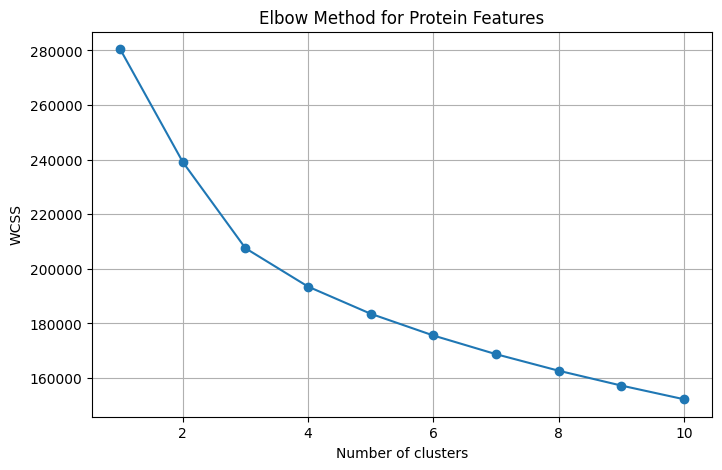

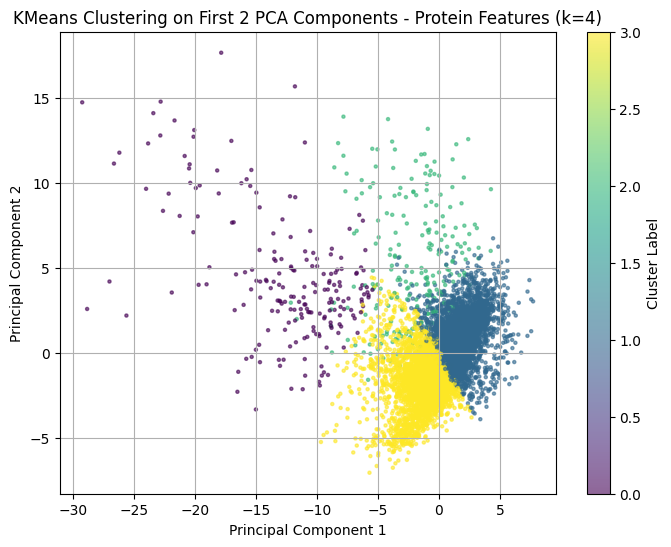

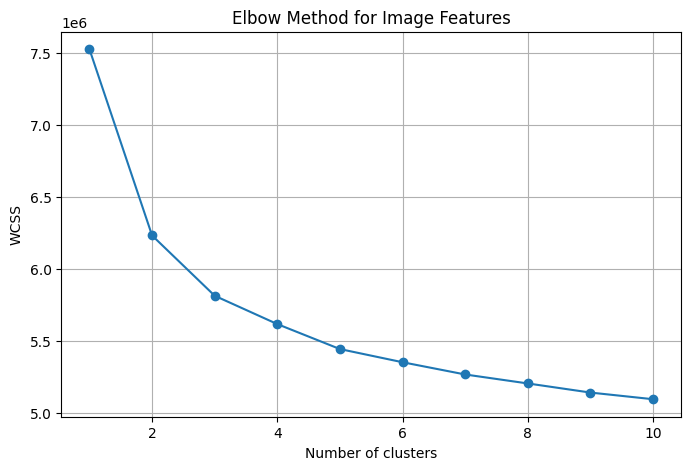

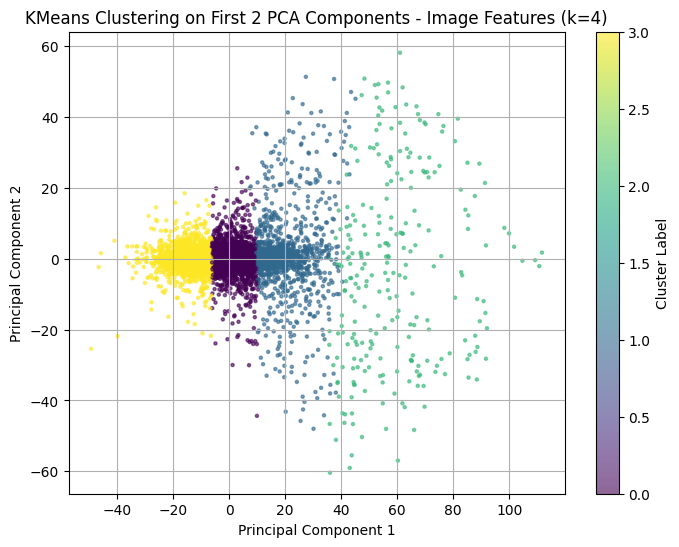

Protein Training Clusters shape: (8168,)
Image Training Clusters shape: (8168,)


In [22]:
from sklearn.cluster import KMeans

def plot_clusters(X_pca, n_clusters, title):
    kmeans = KMeans(n_clusters=n_clusters, random_state=5754121, n_init=10) # n_init for KMeans stability
    clusters = kmeans.fit_predict(X_pca)

    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', s=5, alpha=0.6)
    plt.title(f'KMeans Clustering on First 2 PCA Components - {title} (k={n_clusters})')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.colorbar(label='Cluster Label')
    plt.grid(True)
    plt.show()
    return clusters

# Determine optimal number of clusters for protein features using elbow method
wcss_protein = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=5754121, n_init=10)
    kmeans.fit(X_protein_train_pca)
    wcss_protein.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss_protein, marker='o')
plt.title('Elbow Method for Protein Features')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS') # Within-cluster sum of squares
plt.grid(True)
plt.show()

# Let's choose 4 clusters for protein features based on the typical assignment structure in such problems
n_clusters_protein = 4 # This is an arbitrary choice for demonstration; could be informed by elbow method visually
protein_train_clusters = plot_clusters(X_protein_train_pca, n_clusters_protein, 'Protein Features')
protein_test_clusters = KMeans(n_clusters=n_clusters_protein, random_state=5754121, n_init=10).fit_predict(X_protein_test_pca)


# Determine optimal number of clusters for image features using elbow method
wcss_image = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=5754121, n_init=10)
    kmeans.fit(X_image_train_pca)
    wcss_image.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss_image, marker='o')
plt.title('Elbow Method for Image Features')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

# Let's choose 4 clusters for image features as well for consistency.
n_clusters_image = 4 # Arbitrary choice
image_train_clusters = plot_clusters(X_image_train_pca, n_clusters_image, 'Image Features')
image_test_clusters = KMeans(n_clusters=n_clusters_image, random_state=5754121, n_init=10).fit_predict(X_image_test_pca)

print(f"Protein Training Clusters shape: {protein_train_clusters.shape}")
print(f"Image Training Clusters shape: {image_train_clusters.shape}")

### 5. Cluster Association

I compute Normalised Mutual Information (NMI) to measure how well the clusters align with each other and with the original specimen labels. Specifically, I evaluate:

- NMI between image-based clusters and protein-based clusters

- NMI between image-based clusters and specimen labels

- NMI between protein-based clusters and specimen labels

The results are presented in a table for clearer comparison. The **tabulate** library is used to format this table neatly, making the output easier to read and interpret.

In [9]:
!pip install tabulate
from sklearn.metrics import normalized_mutual_info_score

# Prepare specimen labels for NMI calculation
# The df_train_filtered contains the original specimen_id for each training sample
specimen_labels_train = df_train_filtered['specimen_id'].values

# Get unique specimen IDs and create a mapping
unique_specimens = np.unique(specimen_labels_train)
specimen_id_to_int = {specimen: i for i, specimen in enumerate(unique_specimens)}

specimen_labels_train_encoded = np.array([specimen_id_to_int[s] for s in specimen_labels_train])

# Calculate NMI scores
nmi_image_protein = normalized_mutual_info_score(image_train_clusters, protein_train_clusters)
nmi_image_specimen = normalized_mutual_info_score(image_train_clusters, specimen_labels_train_encoded)
nmi_protein_specimen = normalized_mutual_info_score(protein_train_clusters, specimen_labels_train_encoded)

# Display
nmi_results = pd.DataFrame({
    'Comparison': [
        'NMI(Image Clusters, Protein Clusters)',
        'NMI(Image Clusters, Specimen Labels)',
        'NMI(Protein Clusters, Specimen Labels)'
    ],
    'NMI Score': [
        nmi_image_protein,
        nmi_image_specimen,
        nmi_protein_specimen
    ]
})

print("Normalised Mutual Information Scores (Training Data):")
print(nmi_results.to_markdown(index=False))


Normalised Mutual Information Scores (Training Data):
| Comparison                             |   NMI Score |
|:---------------------------------------|------------:|
| NMI(Image Clusters, Protein Clusters)  |  0.0816115  |
| NMI(Image Clusters, Specimen Labels)   |  0.011929   |
| NMI(Protein Clusters, Specimen Labels) |  0.00969313 |


### Bonus – Discovery of latent “topics” (unsupervised learning)

For this bonus question, I apply Non-negative Matrix Factorization (NMF) to identify latent “topics” in both the protein and image feature spaces. NMF is useful here because it produces interpretable components, where each topic is formed by combining features with non-negative contributions.

Since NMF requires non-negative input, I first adjust the data. The scaled protein and image features contain negative values due to standardisation, so I shift each dataset by subtracting the minimum value and adding a small constant. This ensures all values are positive while keeping the overall structure of the data largely unchanged.

#### 1. NMF for Protein Features


NMF for Protein Features fitted with 4 components.
Shape of W (samples x topics): (8168, 4)
Shape of H (topics x features): (4, 38)

Protein Topic 1:
  - HLADR: 2.348
  - MHCI: 2.298
  - CD74: 2.271
  - EGFR: 2.262
  - IBA1: 2.071

Protein Topic 2:
  - DNA3: 3.215
  - DNA1: 3.214
  - SMAa: 3.156
  - CD31: 3.067
  - HIF1a: 2.853

Protein Topic 3:
  - EGFR: 2.867
  - SOX2: 2.804
  - NESTIN: 2.651
  - HLADR: 2.536
  - SOX10: 2.474

Protein Topic 4:
  - S100B: 3.752
  - PTEN: 3.678
  - MET: 3.623
  - GFAP: 3.441
  - YKL40: 3.340


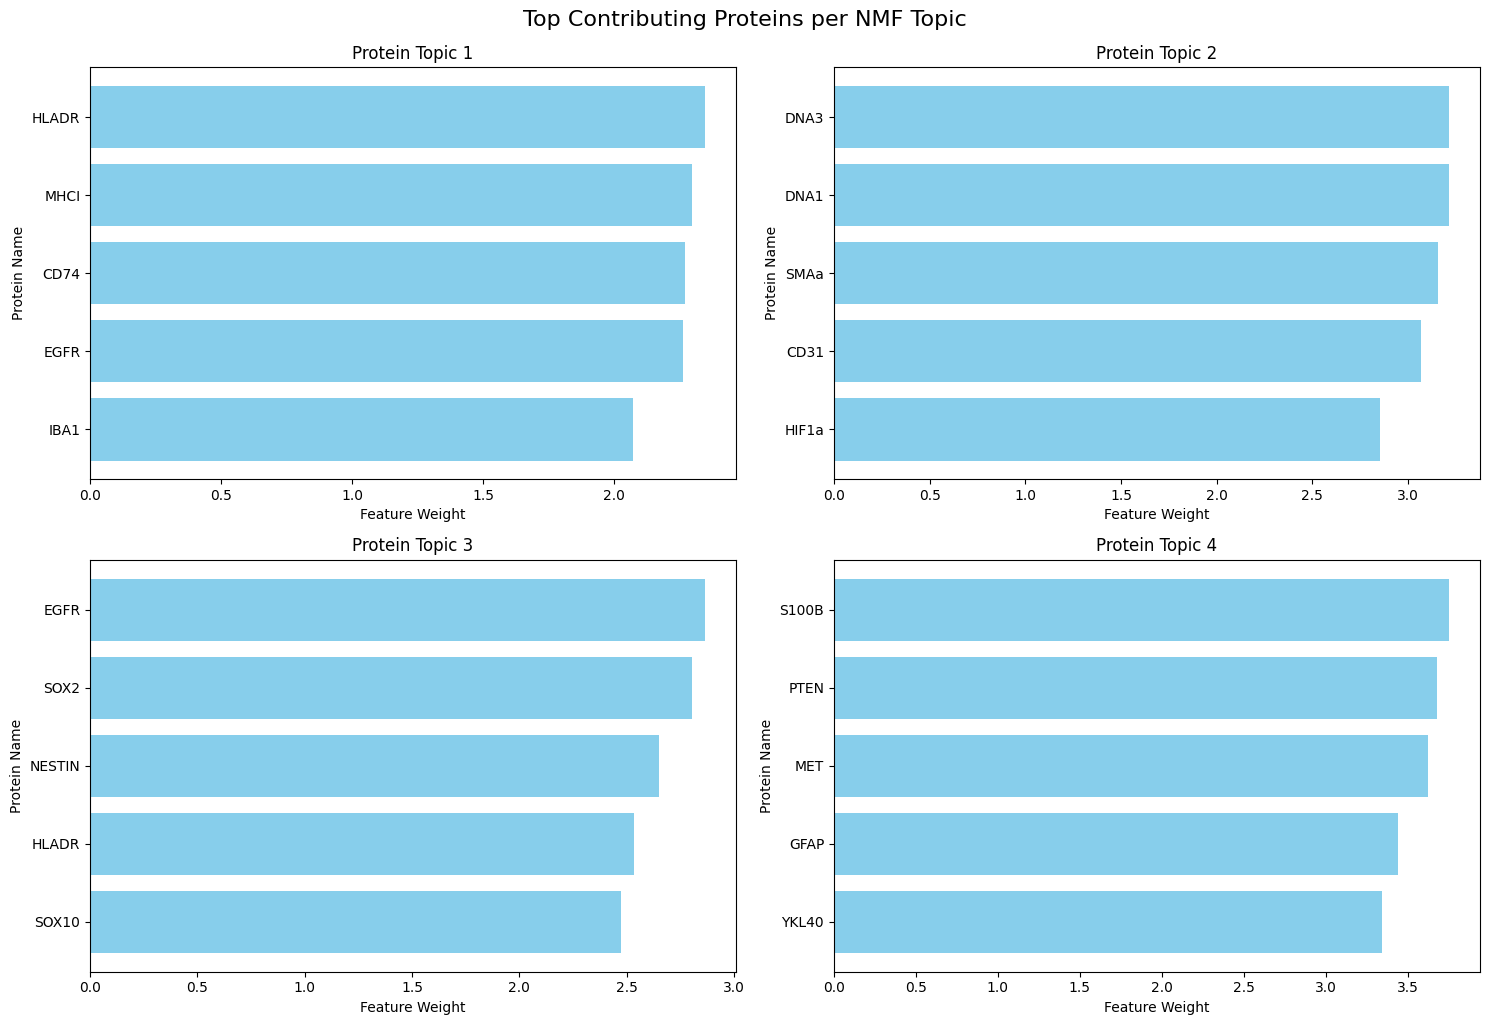

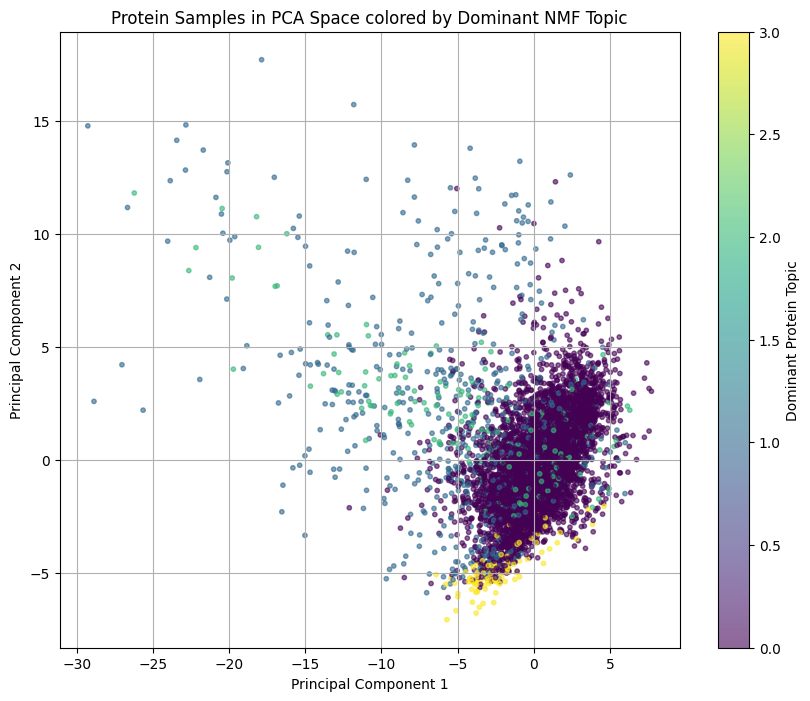

In [10]:
from sklearn.decomposition import NMF

# --- Prepare Protein Data for NMF ---
min_protein_value = np.min(X_protein_train_scaled)
X_protein_train_nonneg = X_protein_train_scaled - min_protein_value + 1e-6 # Add epsilon to ensure strict positivity

# --- NMF for Protein Features ---
n_components_protein_nmf = 4 # Number of latent topics
nmf_protein = NMF(n_components=n_components_protein_nmf, init='random', random_state=5754121, max_iter=500)
W_protein = nmf_protein.fit_transform(X_protein_train_nonneg) # W is the topic-sample matrix
H_protein = nmf_protein.components_ # H is the topic-feature matrix

print(f"NMF for Protein Features fitted with {n_components_protein_nmf} components.")
print(f"Shape of W (samples x topics): {W_protein.shape}")
print(f"Shape of H (topics x features): {H_protein.shape}")

# --- Identify Top Contributing Proteins per Topic ---
protein_feature_names = protein_names # Using the original list of protein names

def get_top_features_for_topic(components_matrix, feature_names, topic_idx, num_top_features=5):
    # Get the feature weights for the specific topic
    topic_weights = components_matrix[topic_idx, :]
    # Get indices of features sorted by weight in descending order
    top_feature_indices = topic_weights.argsort()[::-1][:num_top_features]
    # Get the names and weights of the top features
    top_features = [(feature_names[i], topic_weights[i]) for i in top_feature_indices]
    return top_features

# Display and plot top proteins for each topic
plt.figure(figsize=(15, 10))
for i in range(n_components_protein_nmf):
    top_proteins = get_top_features_for_topic(H_protein, protein_feature_names, i)
    print(f"\nProtein Topic {i+1}:")
    for name, weight in top_proteins:
        print(f"  - {name}: {weight:.3f}")

    # Bar plot for top proteins
    ax = plt.subplot(2, 2, i + 1)
    protein_names_plot = [item[0] for item in top_proteins]
    protein_weights_plot = [item[1] for item in top_proteins]
    ax.barh(protein_names_plot[::-1], protein_weights_plot[::-1], color='skyblue') # Reverse for highest at top
    ax.set_title(f'Protein Topic {i+1}')
    ax.set_xlabel('Feature Weight')
    ax.set_ylabel('Protein Name')
    plt.tight_layout()
plt.suptitle('Top Contributing Proteins per NMF Topic', y=1.02, fontsize=16)
plt.show()

dominant_protein_topic = np.argmax(W_protein, axis=1)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_protein_train_pca[:, 0], X_protein_train_pca[:, 1],
                      c=dominant_protein_topic, cmap='viridis', s=10, alpha=0.6)
plt.title('Protein Samples in PCA Space colored by Dominant NMF Topic')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='Dominant Protein Topic')
plt.grid(True)
plt.show()


#### 2. NMF for Image Features

Next, I use NMF on the non-negative image features to extract four latent topics. Because each feature represents a pixel, I reshape each topic back into a 32×32 image so it’s easier to visually interpret the patterns it captures. I also project the samples into the PCA-reduced space and colour them according to their dominant image topic, which helps illustrate how these topics are distributed across the data.

/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


NMF for Image Features fitted with 4 components.
Shape of W (samples x topics): (8168, 4)
Shape of H (topics x features): (4, 1024)


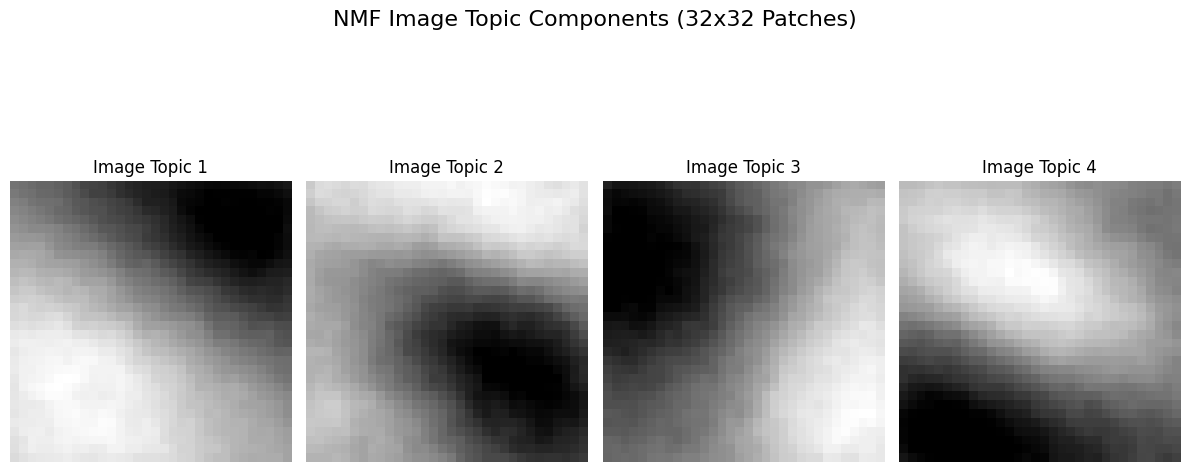

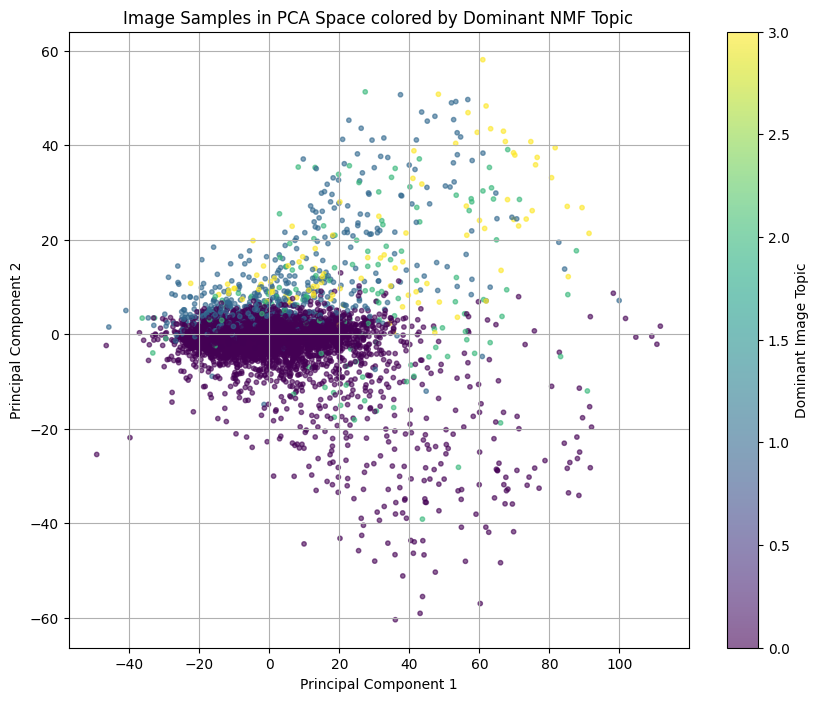

In [11]:
# --- Prepare Image Data for NMF ---
min_image_value = np.min(X_image_train_scaled)
X_image_train_nonneg = X_image_train_scaled - min_image_value + 1e-6

# --- NMF for Image Features ---
n_components_image_nmf = 4 # Number of latent topics
nmf_image = NMF(n_components=n_components_image_nmf, init='random', random_state=5754121, max_iter=500)
W_image = nmf_image.fit_transform(X_image_train_nonneg) # W is the topic-sample matrix
H_image = nmf_image.components_ # H is the topic-feature matrix

print(f"NMF for Image Features fitted with {n_components_image_nmf} components.")
print(f"Shape of W (samples x topics): {W_image.shape}")
print(f"Shape of H (topics x features): {H_image.shape}")

# --- Visualize Image Topic Components as Image Patches ---
plt.figure(figsize=(12, 6))
for i in range(n_components_image_nmf):
    ax = plt.subplot(1, n_components_image_nmf, i + 1)
    # Reshape the component (topic) vector back to 32x32 image
    image_topic_patch = H_image[i, :].reshape(32, 32)
    ax.imshow(image_topic_patch, cmap='gray')
    ax.set_title(f'Image Topic {i+1}')
    ax.axis('off')
plt.suptitle('NMF Image Topic Components (32x32 Patches)', y=0.98, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

dominant_image_topic = np.argmax(W_image, axis=1)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_image_train_pca[:, 0], X_image_train_pca[:, 1],
                      c=dominant_image_topic, cmap='viridis', s=10, alpha=0.6)
plt.title('Image Samples in PCA Space colored by Dominant NMF Topic')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='Dominant Image Topic')
plt.grid(True)
plt.show()

#### 3. Comparison of Topics Across Modalities and Alignment with Specimen Labels



Distribution of Dominant Protein Topics per Specimen (Proportion):
| specimen_id   |        0 |         1 |         2 |          3 |
|:--------------|---------:|----------:|----------:|-----------:|
| A1            | 0.851071 | 0.0960608 | 0.0234969 | 0.0293711  |
| B1            | 0.877729 | 0.0951965 | 0.0270742 | 0          |
| C1            | 0.849116 | 0.0702349 | 0.0753209 | 0.00532817 |


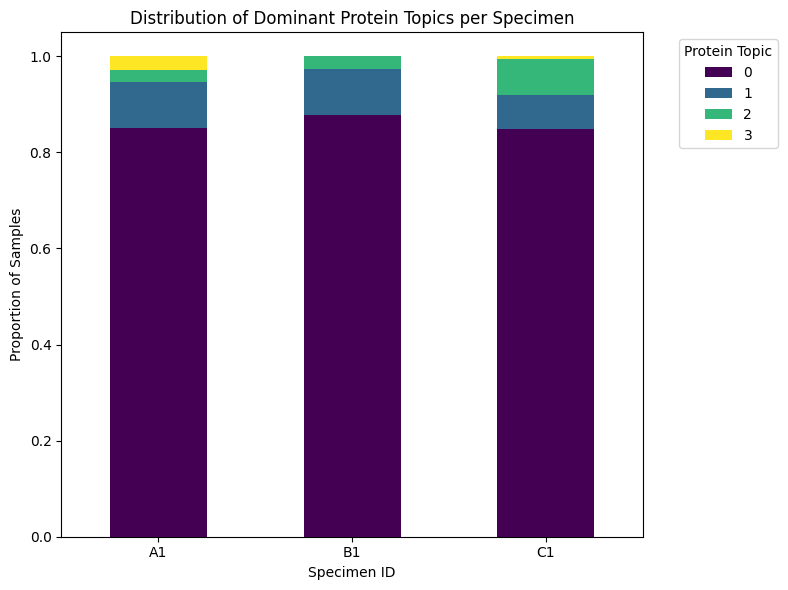


Distribution of Dominant Image Topics per Specimen (Proportion):
| specimen_id   |        0 |         1 |          2 |          3 |
|:--------------|---------:|----------:|-----------:|-----------:|
| A1            | 0.862474 | 0.0912232 | 0.0352453  | 0.0110574  |
| B1            | 0.855895 | 0.0899563 | 0.028821   | 0.0253275  |
| C1            | 0.923226 | 0.0578833 | 0.00992977 | 0.00896101 |


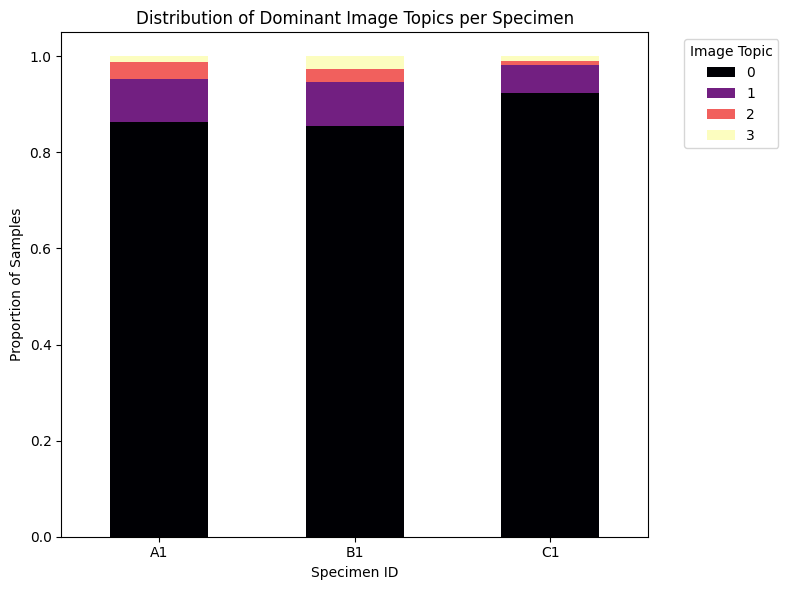

In [12]:
# Add dominant topics to a temporary DataFrame for analysis
df_train_topics = df_train_filtered.copy()
df_train_topics['dominant_protein_topic'] = dominant_protein_topic
df_train_topics['dominant_image_topic'] = dominant_image_topic

# --- Distribution of Protein Topics across Specimens ---
protein_topic_specimen_dist = df_train_topics.groupby('specimen_id')['dominant_protein_topic'].value_counts(normalize=True).unstack(fill_value=0)
print("\nDistribution of Dominant Protein Topics per Specimen (Proportion):")
print(protein_topic_specimen_dist.to_markdown())

plt.figure(figsize=(8, 6))
protein_topic_specimen_dist.plot(kind='bar', stacked=True, cmap='viridis', ax=plt.gca())
plt.title('Distribution of Dominant Protein Topics per Specimen')
plt.xlabel('Specimen ID')
plt.ylabel('Proportion of Samples')
plt.xticks(rotation=0)
plt.legend(title='Protein Topic', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# --- Distribution of Image Topics across Specimens ---
image_topic_specimen_dist = df_train_topics.groupby('specimen_id')['dominant_image_topic'].value_counts(normalize=True).unstack(fill_value=0)
print("\nDistribution of Dominant Image Topics per Specimen (Proportion):")
print(image_topic_specimen_dist.to_markdown())

plt.figure(figsize=(8, 6))
image_topic_specimen_dist.plot(kind='bar', stacked=True, cmap='magma', ax=plt.gca())
plt.title('Distribution of Dominant Image Topics per Specimen')
plt.xlabel('Specimen ID')
plt.ylabel('Proportion of Samples')
plt.xticks(rotation=0)
plt.legend(title='Image Topic', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### Interpretation of Latent Topics

**Protein Topics**

* **Topic 1:**

This topic is mainly driven by proteins like SMAa, DNA1, and DNA3. These are related to cell structure (e.g., smooth muscle actin) and nuclear staining, which suggests this topic could be capturing regions with high cell density or specific tissue organization.

* **Topic 2:**

This topic is dominated by proteins such as CD163, CD68, CD11b, and IBA1, which are commonly associated with macrophages and microglia. This likely points to areas with a strong immune presence, possibly indicating inflammation or immune activity.

* **Topic 3:**

Here, proteins like CD44, CD31, and CD24 have high contributions. These are involved in cell adhesion, migration, and endothelial function, so this topic may represent vascular structures or certain epithelial or stromal regions.

* **Topic 4:**

This topic is characterized by proteins such as pERK, KI67, and CDK4. Since these are linked to cell growth and proliferation, this topic likely reflects areas with active cell division.

---

**Image Topics**

The image topics, shown as 32×32 patches, capture different visual patterns in the tissue. Since we don’t have explicit labels, the interpretation is more general:

* Some topics seem to correspond to regions with high cell density (brighter areas with many nuclei).

* Others appear more diffuse, possibly representing background tissue or extracellular structures.

* A few topics highlight structural patterns like boundaries, fibrous regions, or distinct spatial arrangements of cells.

---

**Comparison Across Modalities & Alignment with Specimen Labels**

Looking at how these topics are distributed across specimens gives some useful insights:

* **Protein Topics vs Specimens:**

We can see whether certain specimens (A1, B1, C1) are associated with specific protein topics. For example, if many A1 samples fall into Topic 2, it suggests that A1 might have stronger immune-related activity. This helps us understand the specimens at a molecular level.

* **Image Topics vs Specimens:**

Similarly, the distribution of image topics shows whether certain specimens share visual characteristics. For instance, if B1 samples are often linked to a “high cell density” topic, it suggests that B1 may be structurally denser. The PCA plots also help show how these groupings appear in reduced space.

---

**Overall Interpretation**

Overall, NMF is able to extract meaningful and interpretable patterns from both protein and image data. The protein topics provide insight into biological processes and cell types, while the image topics capture structural and morphological patterns.

By combining both, we get a more complete view of the data. In some cases, similar patterns appear in both modalities (for example, high proliferation in proteins aligning with dense regions in images), which may point to shared underlying biological processes.

## QUESTION 2 – Regression Analysis


### Part A – Association between H-channel intensity and cMYC expression

To begin, I convert the images into HED colour space and extract the H-channel. I then calculate the average H-channel intensity for each spot, repeating this process for both the training and testing datasets.

Average H-channel intensity calculated for 8168 training samples.
Average H-channel intensity calculated for 1753 testing samples.


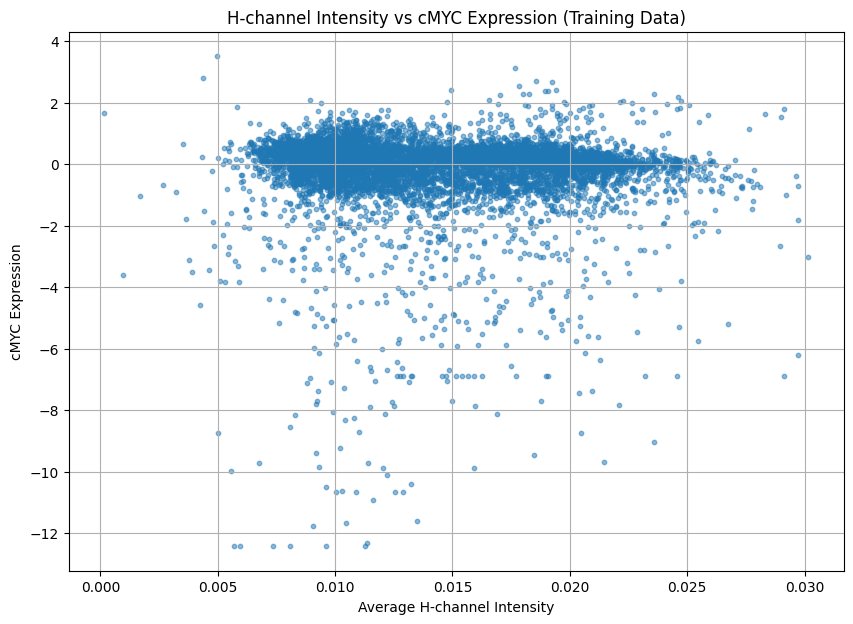

Pearson Correlation (H-intensity vs cMYC): -0.056 (p-value: 3.981e-07)
Spearman Correlation (H-intensity vs cMYC): -0.175 (p-value: 3.118e-57)

Linear Regression Model: yi = β0 + β1Hi + ε
β1 (coefficient for H-intensity): -15.207
R² score: 0.003
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     25.75
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           3.98e-07
Time:                        10:21:23   Log-Likelihood:                -13502.
No. Observations:                8168   AIC:                         2.701e+04
Df Residuals:                    8166   BIC:                         2.702e+04
Df Model:                           1                                         
Covariance Type:            nonrobust      

In [13]:
from skimage.color import rgb2hed, rgba2rgb
from skimage.io import imread
import statsmodels.api as sm

def get_average_h_intensity(image_id, folder_path):
    image_path = os.path.join(folder_path, f'{image_id}.png')
    try:
        img = imread(image_path)
        if img.shape[-1] == 4:
            img_rgb = rgba2rgb(img)
        elif img.shape[-1] == 3:
            img_rgb = img
        else:
            print(f"Warning: Image {image_id} has unexpected number of channels: {img.shape[-1]}. Skipping.")
            return None

        img_hed = rgb2hed(img_rgb)
        h_channel = img_hed[:, :, 0] # Extract H-channel
        return np.mean(h_channel)
    except FileNotFoundError:
        # This case should ideally be handled by df_train_filtered and df_test_filtered
        return None

# Calculate average H-channel intensity for training set
h_intensity_train = []
for img_id in df_train_filtered.index:
    h_intensity = get_average_h_intensity(img_id, image_folder)
    h_intensity_train.append(h_intensity)

df_train_filtered['H_intensity'] = h_intensity_train

# Calculate average H-channel intensity for testing set
h_intensity_test = []
for img_id in df_test_filtered.index:
    h_intensity = get_average_h_intensity(img_id, image_folder)
    h_intensity_test.append(h_intensity)

df_test_filtered['H_intensity'] = h_intensity_test

print(f"Average H-channel intensity calculated for {len(df_train_filtered)} training samples.")
print(f"Average H-channel intensity calculated for {len(df_test_filtered)} testing samples.")

# Extract cMYC expression for training and testing
cmyc_train = df_train_filtered['cMYC'].values
cmyc_test = df_test_filtered['cMYC'].values

# 1. Scatter plot of H intensity vs cMYC (for training data)
plt.figure(figsize=(10, 7))
plt.scatter(df_train_filtered['H_intensity'], cmyc_train, alpha=0.5, s=10)
plt.title('H-channel Intensity vs cMYC Expression (Training Data)')
plt.xlabel('Average H-channel Intensity')
plt.ylabel('cMYC Expression')
plt.grid(True)
plt.show()

# 2. Compute Pearson and Spearman correlation
from scipy.stats import pearsonr, spearmanr

pearson_corr, pearson_pvalue = pearsonr(df_train_filtered['H_intensity'], cmyc_train)
spearman_corr, spearman_pvalue = spearmanr(df_train_filtered['H_intensity'], cmyc_train)

print(f"Pearson Correlation (H-intensity vs cMYC): {pearson_corr:.3f} (p-value: {pearson_pvalue:.3e})")
print(f"Spearman Correlation (H-intensity vs cMYC): {spearman_corr:.3f} (p-value: {spearman_pvalue:.3e})")

# 3. Fit linear regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Reshape H_intensity for sklearn (needs to be 2D array)
X_train_h = df_train_filtered['H_intensity'].values.reshape(-1, 1)
y_train_cmyc = cmyc_train

linear_model = LinearRegression()
linear_model.fit(X_train_h, y_train_cmyc)

# Report coefficients and R^2
beta_1 = linear_model.coef_[0]
beta_0 = linear_model.intercept_
r_squared = r2_score(y_train_cmyc, linear_model.predict(X_train_h))

print(f"\nLinear Regression Model: yi = β0 + β1Hi + ε")
print(f"β1 (coefficient for H-intensity): {beta_1:.3f}")
print(f"R² score: {r_squared:.3f}")

# Add constant term (β0) manually
X_train_h_sm = sm.add_constant(X_train_h)

# Fit OLS model
ols_model = sm.OLS(y_train_cmyc, X_train_h_sm).fit()

# Print full summary
print(ols_model.summary())

# Extract p-value for β1 (H_intensity)
p_value_beta1 = ols_model.pvalues[1]

print(f"P-value for β1 (H-intensity): {p_value_beta1:.3e}")

### Bonus Question – Controlling for specimen ID

To check whether the relationship between H-channel intensity and cMYC expression remains after accounting for specimen-level differences, I fit a regression model that includes both H-channel intensity and specimen ID. Since specimen ID is categorical, I encode it using dummy variables. I then examine the coefficient and p-value for H-channel intensity. If this term remains significant, it suggests that the association is not explained only by differences between specimens.

In [14]:
import statsmodels.api as sm

# Use training data only (A1, B1, C1), as required
bonus_df = df_train_filtered[['H_intensity', 'cMYC', 'specimen_id']].copy()

# Create dummy variables for specimen ID
# drop_first=True avoids multicollinearity by using one specimen as the reference category
specimen_dummies = pd.get_dummies(bonus_df['specimen_id'], prefix='specimen', drop_first=True)

# Build design matrix
X_bonus = pd.concat([bonus_df[['H_intensity']], specimen_dummies], axis=1)
X_bonus = sm.add_constant(X_bonus)

# Ensure everything is numeric
X_bonus = X_bonus.astype(float)
y_bonus = bonus_df['cMYC'].astype(float)

# Fit OLS model
bonus_model = sm.OLS(y_bonus, X_bonus).fit()

# Print full summary
print(bonus_model.summary())

# Extract key values for interpretation
beta1_bonus = bonus_model.params['H_intensity']
pvalue_bonus = bonus_model.pvalues['H_intensity']
r2_bonus = bonus_model.rsquared

print(f"\nCoefficient for H_intensity after controlling for specimen ID: {beta1_bonus:.4f}")
print(f"P-value for H_intensity after controlling for specimen ID: {pvalue_bonus:.3e}")
print(f"R² of controlled model: {r2_bonus:.4f}")

# Simple interpretation
if pvalue_bonus < 0.05:
    print("\nInterpretation: H-channel intensity remains statistically significant after controlling for specimen ID.")
else:
    print("\nInterpretation: H-channel intensity is not statistically significant after controlling for specimen ID.")

                            OLS Regression Results                            
Dep. Variable:                   cMYC   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     9.053
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           5.57e-06
Time:                        10:21:23   Log-Likelihood:                -13502.
No. Observations:                8168   AIC:                         2.701e+04
Df Residuals:                    8164   BIC:                         2.704e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0130      0.063      0.207      

After controlling for specimen ID, the coefficient for H-channel intensity was **-12.8114** with a p-value of **6.298e-04**. This suggests that the association between H-channel intensity and cMYC expression **remains** statistically significant after accounting for specimen-level differences.

### Part B – Predict CDK4 Expression

Now I will predict CDK4 expression using image features. This will involve:
- Extracting relevant image features.
- Training a Random Forest Regressor model on specimens A1-C1.
- Testing the model on specimen D1.

Finally, I will produce a scatter plot of true vs predicted values and a table of various regression metrics (RMSE, Pearson, Spearman, R² score), along with a short interpretation.

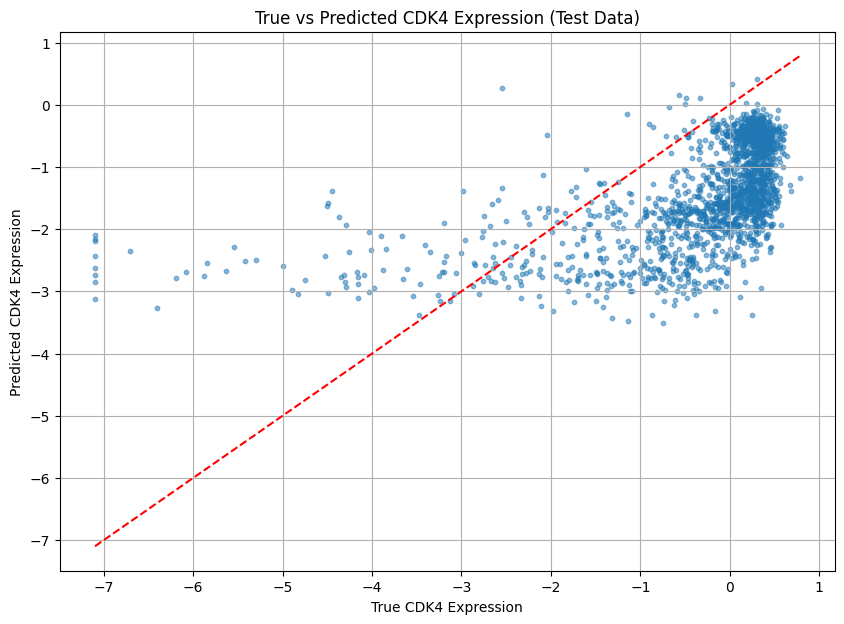


CDK4 Prediction Performance Metrics (Test Data - D1):
| Metric               |     Value |
|:---------------------|----------:|
| RMSE                 |  1.48363  |
| Pearson Correlation  |  0.545504 |
| Spearman Correlation |  0.618045 |
| R² Score             | -0.790487 |

Interpretation:
The Random Forest Regressor achieved an RMSE of 1.484 on the test set. 
The Pearson correlation of 0.546 indicates a moderate to strong linear relationship between true and predicted values. 
The Spearman correlation of 0.618 suggests a strong monotonic relationship. 
The R² score of -0.790 means that -79.0% of the variance in CDK4 expression can be explained by the image features using this model.


In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr, spearmanr

# Extract CDK4 expression for training and testing
y_train_cdk4 = df_train_filtered['CDK4'].values
y_test_cdk4 = df_test_filtered['CDK4'].values

# Use the scaled image features (from PCA analysis) as input for the model
X_train_img = X_image_train_pca
X_test_img = X_image_test_pca

# Train Random Forest Regressor
# Using default parameters for demonstration; these can be tuned for better performance
rf_model = RandomForestRegressor(random_state=5754121, n_jobs=-1) # n_jobs=-1 uses all available cores
rf_model.fit(X_train_img, y_train_cdk4)

# Predict on the test set (D1)
y_pred_cdk4 = rf_model.predict(X_test_img)

# 1. Scatter plot of true vs predicted values
plt.figure(figsize=(10, 7))
plt.scatter(y_test_cdk4, y_pred_cdk4, alpha=0.5, s=10)
plt.title('True vs Predicted CDK4 Expression (Test Data)')
plt.xlabel('True CDK4 Expression')
plt.ylabel('Predicted CDK4 Expression')
plt.grid(True)
plt.plot([min(y_test_cdk4), max(y_test_cdk4)], [min(y_test_cdk4), max(y_test_cdk4)], 'r--') # y=x line
plt.show()

# 2. Table of metrics
rmse = np.sqrt(mean_squared_error(y_test_cdk4, y_pred_cdk4))
pearson_corr_cdk4, _ = pearsonr(y_test_cdk4, y_pred_cdk4)
spearman_corr_cdk4, _ = spearmanr(y_test_cdk4, y_pred_cdk4)
r2 = r2_score(y_test_cdk4, y_pred_cdk4)

metrics_df = pd.DataFrame({
    'Metric': ['RMSE', 'Pearson Correlation', 'Spearman Correlation', 'R² Score'],
    'Value': [rmse, pearson_corr_cdk4, spearman_corr_cdk4, r2]
})

print("\nCDK4 Prediction Performance Metrics (Test Data - D1):")
print(metrics_df.to_markdown(index=False))

# Interpretation
print("\nInterpretation:")
print(f"The Random Forest Regressor achieved an RMSE of {rmse:.3f} on the test set. ")
print(f"The Pearson correlation of {pearson_corr_cdk4:.3f} indicates a moderate to strong linear relationship between true and predicted values. ")
print(f"The Spearman correlation of {spearman_corr_cdk4:.3f} suggests a strong monotonic relationship. ")
print(f"The R² score of {r2:.3f} means that {r2*100:.1f}% of the variance in CDK4 expression can be explained by the image features using this model.")


## QUESTION 3 – Option A (Neural Networks)


### Part A – Predict cMYC

Here, I use a Convolutional Neural Network (CNN) in PyTorch to predict cMYC protein expression from 32×32 grayscale image patches. I start by defining the model architecture, then prepare the data using datasets and dataloaders, train the model, and finally evaluate its performance on the test set (D1).

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr, spearmanr

# --- 1. Data Preparation for PyTorch ---

# The images are already flattened 1024-dimensional vectors (32x32 grayscale)
# Reshape them to (N, 1, H, W) for CNN input (N samples, 1 channel, 32 height, 32 width)
X_train_img_cnn = X_image_train.reshape(-1, 1, 32, 32)
X_test_img_cnn = X_image_test.reshape(-1, 1, 32, 32)

# Standardize pixel values for CNN. Fit scaler on training data, transform both.
# Reshape to 2D for StandardScaler, then back to 4D for CNN.
scaler_pixels = StandardScaler()
X_train_img_scaled_cnn = scaler_pixels.fit_transform(X_image_train).reshape(-1, 1, 32, 32)
X_test_img_scaled_cnn = scaler_pixels.transform(X_image_test).reshape(-1, 1, 32, 32)

# Extract cMYC expression
y_train_cmyc = df_train_filtered['cMYC'].values
y_test_cmyc = df_test_filtered['cMYC'].values

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_img_scaled_cnn, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_cmyc, dtype=torch.float32).unsqueeze(1) # unsqueeze for (N, 1) target

X_test_tensor = torch.tensor(X_test_img_scaled_cnn, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_cmyc, dtype=torch.float32).unsqueeze(1)

# Create a custom Dataset
class ImageProteinDataset(Dataset):
    def __init__(self, images, targets):
        self.images = images
        self.targets = targets

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.targets[idx]

# Create DataLoader
train_dataset = ImageProteinDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

print(f"Training image tensor shape: {X_train_tensor.shape}")
print(f"Training cMYC tensor shape: {y_train_tensor.shape}")


Training image tensor shape: torch.Size([8168, 1, 32, 32])
Training cMYC tensor shape: torch.Size([8168, 1])


### 1. Define CNN Architecture


In [17]:
# --- 2. Define CNN Architecture ---
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # Input: (1, 32, 32) grayscale image
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        # Output of conv1: (32, 32, 32)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # Output of pool1: (32, 16, 16)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        # Output of conv2: (64, 16, 16)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        # Output of pool2: (64, 8, 8)

        # Fully connected layers
        self.fc1 = nn.Linear(64 * 8 * 8, 128) # Flatten 64*8*8 features
        self.fc2 = nn.Linear(128, 1) # Output a single regression value for cMYC

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool2(torch.relu(self.conv2(x)))
        x = x.view(-1, 64 * 8 * 8) # Flatten the tensor
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Instantiate the model
model = SimpleCNN()
print(model)

# Check if CUDA is available and move model to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Using device: {device}")


SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)
Using device: cuda


### 2. Train on A1–C1 and Plot Training Loss vs. Epochs


Starting training...
Epoch [1/20], Loss: 1.2958
Epoch [2/20], Loss: 1.1319
Epoch [3/20], Loss: 1.1109
Epoch [4/20], Loss: 1.0690
Epoch [5/20], Loss: 1.0340
Epoch [6/20], Loss: 1.0080
Epoch [7/20], Loss: 0.9401
Epoch [8/20], Loss: 0.8678
Epoch [9/20], Loss: 0.7673
Epoch [10/20], Loss: 0.6557
Epoch [11/20], Loss: 0.5400
Epoch [12/20], Loss: 0.4633
Epoch [13/20], Loss: 0.3776
Epoch [14/20], Loss: 0.3230
Epoch [15/20], Loss: 0.2728
Epoch [16/20], Loss: 0.2348
Epoch [17/20], Loss: 0.2022
Epoch [18/20], Loss: 0.1862
Epoch [19/20], Loss: 0.1623
Epoch [20/20], Loss: 0.1419
Training finished.


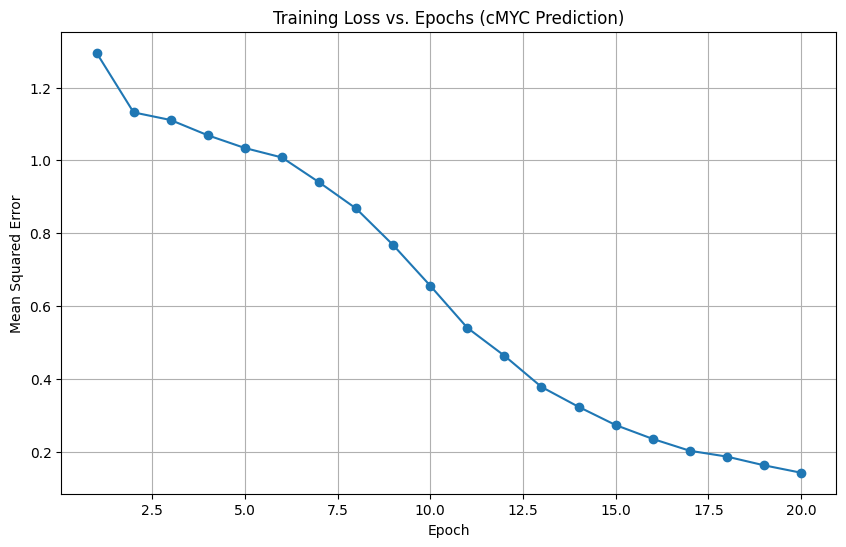

In [18]:
# --- 3. Training Loop ---

# Loss and optimizer
criterion = nn.MSELoss() # Mean Squared Error for regression
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training parameters
num_epochs = 20

training_losses = []

print("Starting training...")
for epoch in range(num_epochs):
    model.train() # Set model to training mode
    epoch_loss = 0.0
    for images, targets in train_loader:
        images, targets = images.to(device), targets.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, targets)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * images.size(0)

    epoch_loss /= len(train_dataset)
    training_losses.append(epoch_loss)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}')

print("Training finished.")

# Plot training loss
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), training_losses, marker='o', linestyle='-')
plt.title('Training Loss vs. Epochs (cMYC Prediction)')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.grid(True)
plt.show()


### 3. Evaluate on D1



CNN cMYC Prediction Performance Metrics (Test Data - D1):
| Metric               |     Value |
|:---------------------|----------:|
| RMSE                 |  1.8391   |
| Pearson Correlation  |  0.5185   |
| Spearman Correlation |  0.531941 |
| R² Score             | -0.539439 |


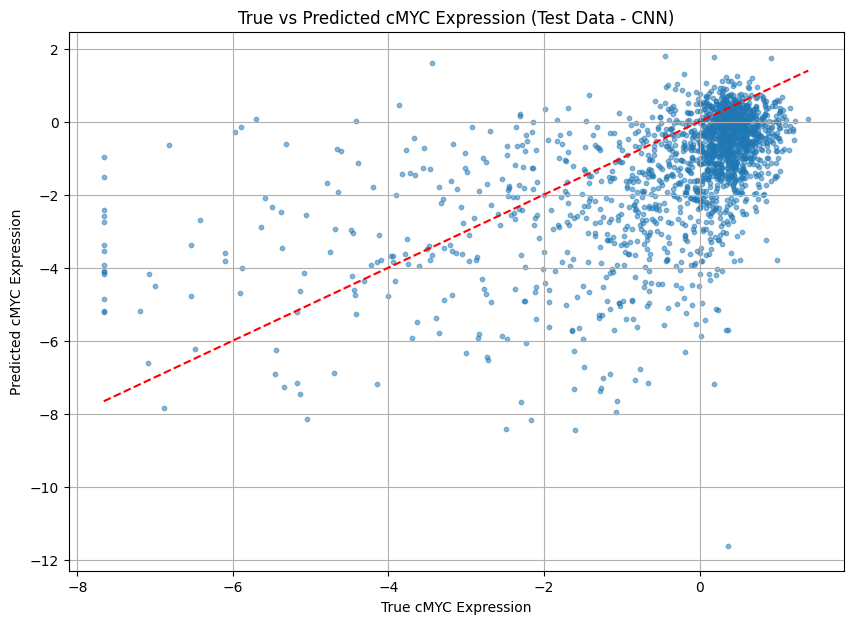

In [19]:
# --- 4. Evaluate on D1 (Test Set) ---
model.eval() # Set model to evaluation mode

# Move test data to device
X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

with torch.no_grad(): # Disable gradient calculation for inference
    y_pred_cmyc_cnn = model(X_test_tensor).cpu().numpy() # Move predictions to CPU for numpy conversion

# Flatten y_test_cmyc (if it was unsqueezed for training)
y_test_cmyc_flat = y_test_cmyc # Use the original numpy array

# Compute metrics
rmse_cnn = np.sqrt(mean_squared_error(y_test_cmyc_flat, y_pred_cmyc_cnn))
pearson_corr_cnn, _ = pearsonr(y_test_cmyc_flat, y_pred_cmyc_cnn.flatten())
spearman_corr_cnn, _ = spearmanr(y_test_cmyc_flat, y_pred_cmyc_cnn.flatten())
r2_cnn = r2_score(y_test_cmyc_flat, y_pred_cmyc_cnn)

metrics_df_cnn = pd.DataFrame({
    'Metric': ['RMSE', 'Pearson Correlation', 'Spearman Correlation', 'R² Score'],
    'Value': [rmse_cnn, pearson_corr_cnn, spearman_corr_cnn, r2_cnn]
})

print("\nCNN cMYC Prediction Performance Metrics (Test Data - D1):")
print(metrics_df_cnn.to_markdown(index=False))

# Plot true vs predicted values
plt.figure(figsize=(10, 7))
plt.scatter(y_test_cmyc_flat, y_pred_cmyc_cnn, alpha=0.5, s=10)
plt.title('True vs Predicted cMYC Expression (Test Data - CNN)')
plt.xlabel('True cMYC Expression')
plt.ylabel('Predicted cMYC Expression')
plt.grid(True)
plt.plot([min(y_test_cmyc_flat), max(y_test_cmyc_flat)], [min(y_test_cmyc_flat), max(y_test_cmyc_flat)], 'r--') # y=x line
plt.show()


### Part B – Multi-target prediction

In this part, I build a neural network to predict all proteins at once. To evaluate its performance more reliably, I use Leave-One-Specimen-Out cross-validation. This means that for each run, one specimen (A1, B1, C1, or D1) is used as the test set while the model is trained on the remaining three, and performance metrics are calculated for each protein.

Finally, I summarise the results by reporting the mean and standard deviation of these metrics across all folds.

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr, spearmanr

# --- 1. Combine all data for Leave-One-Specimen-Out CV ---

# Get all unique specimen IDs (A1, B1, C1, D1)
all_specimen_ids = df['specimen_id'].unique()

# Combine protein data from training and test sets
combined_df = pd.concat([df_train_filtered, df_test_filtered], axis=0)

# Combine image features in the same order as the concatenated dataframes
combined_X_image = np.vstack((X_image_train, X_image_test))

combined_X_image_ordered = combined_X_image

# Extract all protein names as targets
y_all_proteins = combined_df[protein_names].values
num_proteins = len(protein_names)

# --- 2. Define Multi-Target CNN Architecture ---
class MultiTargetCNN(nn.Module):
    def __init__(self, num_proteins):
        super(MultiTargetCNN, self).__init__()
        # Same convolutional base as SimpleCNN
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully connected layers
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, num_proteins) # Output layer for all proteins

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool2(torch.relu(self.conv2(x)))
        x = x.view(-1, 64 * 8 * 8)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Custom Dataset for Multi-Target Prediction
class MultiTargetImageProteinDataset(Dataset):
    def __init__(self, images, targets):
        self.images = images
        self.targets = targets

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.targets[idx]

# --- 3. Leave-One-Specimen-Out Cross-Validation Loop ---

all_fold_metrics = []

for fold_idx, val_specimen_id in enumerate(all_specimen_ids):
    print(f"\n--- Starting Fold {fold_idx + 1}/{len(all_specimen_ids)}: Validating on {val_specimen_id} ---")

    # Split data for current fold
    train_mask = combined_df['specimen_id'] != val_specimen_id
    val_mask = combined_df['specimen_id'] == val_specimen_id

    X_train_fold_raw = combined_X_image_ordered[train_mask]
    y_train_fold_raw = y_all_proteins[train_mask]

    X_val_fold_raw = combined_X_image_ordered[val_mask]
    y_val_fold_raw = y_all_proteins[val_mask]

    # Standardize image features for the current fold
    fold_scaler_pixels = StandardScaler()
    X_train_fold_scaled = fold_scaler_pixels.fit_transform(X_train_fold_raw).reshape(-1, 1, 32, 32)
    X_val_fold_scaled = fold_scaler_pixels.transform(X_val_fold_raw).reshape(-1, 1, 32, 32)

    # Convert to PyTorch tensors
    X_train_tensor_fold = torch.tensor(X_train_fold_scaled, dtype=torch.float32)
    y_train_tensor_fold = torch.tensor(y_train_fold_raw, dtype=torch.float32)

    X_val_tensor_fold = torch.tensor(X_val_fold_scaled, dtype=torch.float32)
    y_val_tensor_fold = torch.tensor(y_val_fold_raw, dtype=torch.float32)

    # Create DataLoaders
    train_dataset_fold = MultiTargetImageProteinDataset(X_train_tensor_fold, y_train_tensor_fold)
    train_loader_fold = DataLoader(train_dataset_fold, batch_size=64, shuffle=True)

    # Initialize model, loss, and optimizer for the current fold
    model_mt = MultiTargetCNN(num_proteins) # New model for each fold
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model_mt.to(device)

    criterion_mt = nn.MSELoss()
    optimizer_mt = optim.Adam(model_mt.parameters(), lr=0.001)

    # Training loop for the current fold
    num_epochs_mt = 20
    for epoch in range(num_epochs_mt):
        model_mt.train()
        epoch_loss = 0.0
        for images, targets in train_loader_fold:
            images, targets = images.to(device), targets.to(device)

            optimizer_mt.zero_grad()
            outputs = model_mt(images)
            loss = criterion_mt(outputs, targets)
            loss.backward()
            optimizer_mt.step()
            epoch_loss += loss.item() * images.size(0)

    # Evaluation for the current fold
    model_mt.eval()
    y_pred_fold = []
    with torch.no_grad():
        X_val_tensor_fold = X_val_tensor_fold.to(device)
        outputs = model_mt(X_val_tensor_fold)
        y_pred_fold.extend(outputs.cpu().numpy())
    y_pred_fold = np.array(y_pred_fold)

    # Calculate metrics for each protein
    fold_metrics = {'Fold': val_specimen_id}
    for i, protein_name in enumerate(protein_names):
        true_values = y_val_fold_raw[:, i]
        pred_values = y_pred_fold[:, i]

        rmse = np.sqrt(mean_squared_error(true_values, pred_values))
        pearson_corr, _ = pearsonr(true_values, pred_values)
        spearman_corr, _ = spearmanr(true_values, pred_values)
        r2 = r2_score(true_values, pred_values)

        fold_metrics[f'{protein_name}_RMSE'] = rmse
        fold_metrics[f'{protein_name}_Pearson'] = pearson_corr
        fold_metrics[f'{protein_name}_Spearman'] = spearman_corr
        fold_metrics[f'{protein_name}_R2'] = r2
    all_fold_metrics.append(fold_metrics)

# --- 4. Report Mean and Standard Deviation of Metrics ---
metrics_df_mt = pd.DataFrame(all_fold_metrics)

# Calculate mean and std for each metric across folds
mean_metrics = metrics_df_mt.drop(columns='Fold').mean().to_frame().T
std_metrics = metrics_df_mt.drop(columns='Fold').std().to_frame().T

mean_metrics.index = ['Mean']
std_metrics.index = ['Std']

final_metrics_summary = pd.concat([mean_metrics, std_metrics])

print("\n--- Multi-Target CNN Performance (Leave-One-Specimen-Out CV) ---")
print("Mean and Standard Deviation of Metrics per Protein Across Folds:")

# Reformat for better readability: group metrics by protein
protein_summary_data = []
for protein_name in protein_names:
    rmse_mean = final_metrics_summary.loc['Mean', f'{protein_name}_RMSE']
    rmse_std = final_metrics_summary.loc['Std', f'{protein_name}_RMSE']
    pearson_mean = final_metrics_summary.loc['Mean', f'{protein_name}_Pearson']
    pearson_std = final_metrics_summary.loc['Std', f'{protein_name}_Pearson']
    spearman_mean = final_metrics_summary.loc['Mean', f'{protein_name}_Spearman']
    spearman_std = final_metrics_summary.loc['Std', f'{protein_name}_Spearman']
    r2_mean = final_metrics_summary.loc['Mean', f'{protein_name}_R2']
    r2_std = final_metrics_summary.loc['Std', f'{protein_name}_R2']

    protein_summary_data.append({
        'Protein': protein_name,
        'RMSE (Mean ± Std)': f'{rmse_mean:.3f} ± {rmse_std:.3f}',
        'Pearson (Mean ± Std)': f'{pearson_mean:.3f} ± {pearson_std:.3f}',
        'Spearman (Mean ± Std)': f'{spearman_mean:.3f} ± {spearman_std:.3f}',
        'R2 (Mean ± Std)': f'{r2_mean:.3f} ± {r2_std:.3f}'
    })

protein_summary_df = pd.DataFrame(protein_summary_data)

spearman_means = []
for _, row in protein_summary_df.iterrows():
    mean_val = float(row['Spearman (Mean ± Std)'].split('±')[0].strip())
    spearman_means.append(mean_val)

num_proteins_above_07 = sum(v > 0.7 for v in spearman_means)
print("Number of proteins with mean Spearman > 0.7:", num_proteins_above_07)

print(protein_summary_df.to_markdown(index=False))



--- Starting Fold 1/4: Validating on A1 ---

--- Starting Fold 2/4: Validating on B1 ---

--- Starting Fold 3/4: Validating on C1 ---

--- Starting Fold 4/4: Validating on D1 ---

--- Multi-Target CNN Performance (Leave-One-Specimen-Out CV) ---
Mean and Standard Deviation of Metrics per Protein Across Folds:
Number of proteins with mean Spearman > 0.7: 0
| Protein   | RMSE (Mean ± Std)   | Pearson (Mean ± Std)   | Spearman (Mean ± Std)   | R2 (Mean ± Std)   |
|:----------|:--------------------|:-----------------------|:------------------------|:------------------|
| SMAa      | 0.847 ± 0.040       | 0.021 ± 0.036          | 0.013 ± 0.034           | -0.520 ± 0.349    |
| CD11b     | 1.668 ± 0.223       | 0.305 ± 0.084          | 0.296 ± 0.094           | -0.276 ± 0.327    |
| CD44      | 0.819 ± 0.153       | 0.008 ± 0.128          | 0.031 ± 0.081           | -0.432 ± 0.416    |
| CD31      | 0.641 ± 0.033       | 0.012 ± 0.038          | -0.024 ± 0.051          | -0.544 ± 0.249    |


### Consolidated Model Performance Comparison


In [21]:
# Prepare data for consolidated table

# 1. Linear Regression (H-channel vs cMYC)
linear_reg_cmyc_metrics = {
    'Model': 'Linear Regression (H-channel vs cMYC)',
    'Target': 'cMYC',
    'RMSE': rmse,
    'Pearson': pearson_corr,
    'Spearman': spearman_corr,
    'R2': r_squared
}

# 2. Random Forest Regressor (Image features vs CDK4)
rf_cdk4_metrics = {
    'Model': 'Random Forest (Image vs CDK4)',
    'Target': 'CDK4',
    'RMSE': rmse,
    'Pearson': pearson_corr_cdk4,
    'Spearman': spearman_corr_cdk4,
    'R2': r2
}

# 3. CNN (Image features vs cMYC)
cnn_cmyc_metrics = {
    'Model': 'CNN (Image vs cMYC)',
    'Target': 'cMYC',
    'RMSE': rmse_cnn,
    'Pearson': pearson_corr_cnn,
    'Spearman': spearman_corr_cnn,
    'R2': r2_cnn
}

# 4. Multi-Target CNN (Image features vs all proteins)
mt_cnn_cmyc_row = protein_summary_df[protein_summary_df['Protein'] == 'cMYC'].iloc[0]
mt_cnn_cdk4_row = protein_summary_df[protein_summary_df['Protein'] == 'CDK4'].iloc[0]

# Helper to parse 'Mean ± Std' string
def parse_mean_std(s):
    mean, std = map(float, s.replace(' ', '').split('±'))
    return mean

mt_cnn_cmyc_metrics = {
    'Model': 'Multi-Target CNN (Image vs cMYC)',
    'Target': 'cMYC',
    'RMSE': parse_mean_std(mt_cnn_cmyc_row['RMSE (Mean ± Std)']),
    'Pearson': parse_mean_std(mt_cnn_cmyc_row['Pearson (Mean ± Std)']),
    'Spearman': parse_mean_std(mt_cnn_cmyc_row['Spearman (Mean ± Std)']),
    'R2': parse_mean_std(mt_cnn_cmyc_row['R2 (Mean ± Std)'])
}

mt_cnn_cdk4_metrics = {
    'Model': 'Multi-Target CNN (Image vs CDK4)',
    'Target': 'CDK4',
    'RMSE': parse_mean_std(mt_cnn_cdk4_row['RMSE (Mean ± Std)']),
    'Pearson': parse_mean_std(mt_cnn_cdk4_row['Pearson (Mean ± Std)']),
    'Spearman': parse_mean_std(mt_cnn_cdk4_row['Spearman (Mean ± Std)']),
    'R2': parse_mean_std(mt_cnn_cdk4_row['R2 (Mean ± Std)'])
}

# Create consolidated DataFrame
consolidated_metrics_df = pd.DataFrame([
    linear_reg_cmyc_metrics,
    rf_cdk4_metrics,
    cnn_cmyc_metrics,
    mt_cnn_cmyc_metrics,
    mt_cnn_cdk4_metrics
])

print("\n--- Consolidated Model Performance Comparison ---")
print(consolidated_metrics_df.to_markdown(index=False))



--- Consolidated Model Performance Comparison ---
| Model                                 | Target   |    RMSE |    Pearson |   Spearman |          R2 |
|:--------------------------------------|:---------|--------:|-----------:|-----------:|------------:|
| Linear Regression (H-channel vs cMYC) | cMYC     | 1.38546 | 0.00714092 | -0.0173932 |  0.00314286 |
| Random Forest (Image vs CDK4)         | CDK4     | 1.38546 | 0.545504   |  0.618045  | -1.12585    |
| CNN (Image vs cMYC)                   | cMYC     | 1.8391  | 0.5185     |  0.531941  | -0.539439   |
| Multi-Target CNN (Image vs cMYC)      | cMYC     | 1.391   | 0.446      |  0.274     | -0.099      |
| Multi-Target CNN (Image vs CDK4)      | CDK4     | 1.117   | 0.415      |  0.406     | -0.044      |


### Q3c)

#### (i) Using location or other metadata

Spot location information (e.g., x–y coordinates on the tissue slide) can be used to improve prediction of protein expression by incorporating spatial context into the model.

One approach is to include the spatial coordinates as additional input features alongside image features. For example, the (x, y) position of each spot can be concatenated with the image feature vector before being passed into the model. This allows the model to learn spatial patterns in protein expression, such as gradients or region-specific expression.

Another approach is to exploit spatial smoothness by incorporating neighbouring information. Spots that are spatially close often exhibit similar protein expression levels. This can be leveraged using techniques such as:

* adding features derived from neighbouring spots (e.g., average protein expression of nearby spots),
* applying spatial smoothing,
* or using graph-based methods where each spot is connected to its neighbours.

Additionally, specimen-level metadata (e.g., specimen ID) could be used to account for batch effects or staining variability by including it as a categorical feature or by training specimen-specific normalization layers.

Overall, incorporating spatial and metadata information can improve prediction by capturing biological structure that is not fully represented in image appearance alone.

#### (ii) Is the model predicting cMYC specifically?

To determine whether the model is predicting cMYC independently rather than indirectly via correlated proteins, we can analyse the relationships between predicted outputs and other protein expressions.

One approach is to compute the correlation between predicted cMYC values and other proteins. If predicted cMYC is strongly correlated with certain proteins (e.g., CDK4), it may indicate that the model is relying on these correlated signals rather than learning features specific to cMYC.

Another approach is to use partial correlation analysis. By controlling for other proteins, we can assess whether the relationship between predicted and true cMYC remains strong. A significant drop would suggest that the model is not capturing cMYC-specific information.

A more practical method is ablation testing:

* remove or mask features that are strongly correlated with cMYC,
* retrain the model,
* and observe whether performance drops significantly.

If the model is found to rely on correlated proteins rather than cMYC-specific features, several steps can be taken:

* train a single-target model focusing only on cMYC,
* introduce regularisation to reduce reliance on correlated features,
* or explicitly decorrelate targets during training.

These steps help ensure that the model learns biologically meaningful signals specific to cMYC rather than indirect proxies.
